In [1]:
import os
import cv2
import numpy as np

IMAGE_SIZE = (32, 32)

# ucitavanje samo bounding boxa oko sake
def load_dataset_bounding_box_only(image_dir, label_dir, image_size=IMAGE_SIZE):
    X = []
    y = []

    image_extensions = (".jpg", ".jpeg", ".png")

    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith(image_extensions)
    ]

    print(f"Found {len(image_files)} images in {image_dir}")

    for filename in image_files:

        image_path = os.path.join(image_dir, filename)

        label_filename = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(label_dir, label_filename)

        if not os.path.exists(label_path):
            print(f"Missing label: {label_filename}")
            continue

        with open(label_path, "r") as f:
            first_line = f.readline().strip()

        if first_line == "":
            print(f"Empty label file: {label_filename}")
            continue

        parts = first_line.split()

        if len(parts) < 5:
            print(f"Invalid label file: {label_filename}")
            continue

        class_id = int(parts[0])

        # koordinate boudning boxa oko sake su 4 broja nakon klase
        x_center = float(parts[1])
        y_center = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])

        img = cv2.imread(image_path)

        if img is None:
            print(f"Failed to load: {filename}")
            continue

        h, w = img.shape[:2]

        # Konverzija normalizovanih koordinata u piksele na slici
        x_center *= w
        y_center *= h
        box_width *= w
        box_height *= h

        # dodavanje margine oko bounding boxa
        margin = 0.10
        box_width *= (1 + margin)
        box_height *= (1 + margin)

        # donje levo i gornje desno teme bounding boxa
        x1 = int(x_center - box_width / 2)
        y1 = int(y_center - box_height / 2)
        x2 = int(x_center + box_width / 2)
        y2 = int(y_center + box_height / 2)

        # Odsecanje u slucaju da su koordinate nevalidne
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        # Preskakanje nelegalnih slucajeva
        if x2 <= x1 or y2 <= y1:
            print(f"Invalid crop for {filename}")
            continue

        # Obsecanje slike
        img = img[y1:y2, x1:x2]

        # Konverzija u greyscale
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Da ne bi doslo do distorzije, formira se crni
        # kvadrat sa stranicom velicine max od dimenzija bounding boxa
        
        h_crop, w_crop = img.shape
        
        side = max(h_crop, w_crop)
        
        square = np.zeros((side, side), dtype=np.uint8)
        
        # Centriranje opsecene ruke u kvadrat
        y_offset = (side - h_crop) // 2
        x_offset = (side - w_crop) // 2
        
        square[
            y_offset:y_offset + h_crop,
            x_offset:x_offset + w_crop
        ] = img
        
        img = cv2.resize(square, image_size, interpolation=cv2.INTER_AREA)

        # normalizacija vrednosti piksela
        img = img.astype(np.float32) / 255.0
        img = img.flatten()

        X.append(img)
        y.append(class_id)

    X = np.array(X)
    y = np.array(y)

    print(f"Loaded {len(X)} samples.")
    print("Classes:", np.unique(y))

    return X, y

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

In [3]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


def find_best_parameters(
    train_image_dir,
    train_label_dir,
    validation_image_dir,
    validation_label_dir,
    img_sizes,
    C_values,
    gammas,
    load_func
):
    results = {}

    for img_size in img_sizes:

        X_train, y_train = load_func(
            train_image_dir,
            train_label_dir,
            img_size
        )

        X_val, y_val = load_func(
            validation_image_dir,
            validation_label_dir,
            img_size
        )

        for gamma in gammas:
            for C in C_values:

                model = SVC(
                        C=C,
                        kernel="rbf",
                        gamma=gamma
                    )

                model.fit(X_train, y_train)

                y_pred = model.predict(X_val)

                acc = accuracy_score(y_val, y_pred)

                results[acc] = (img_size, C, gamma)

                print(
                    f"size={img_size}, kernel=rbf, C={C}, gamma={gamma}, accuracy={acc:.4f}"
                )

    best_acc = max(results)

    return best_acc, results[best_acc]

In [4]:
TRAIN_IMAGE_DIR = "../../../fingers_yolo/images/train"
TRAIN_LABEL_DIR = "../../../fingers_yolo/labels/train"
VAL_IMAGE_DIR = "../../../fingers_yolo/images/val"
VAL_LABEL_DIR = "../../../fingers_yolo/labels/val"

IMAGE_SIZES = [
    (16,16),
    (32,32)
]

C_VALUES = [0.1, 1, 10]

GAMMAS = [0.1, 1, 10]

acc, params = find_best_parameters(
    TRAIN_IMAGE_DIR,
    TRAIN_LABEL_DIR,
    VAL_IMAGE_DIR,
    VAL_LABEL_DIR,
    IMAGE_SIZES,
    C_VALUES,
    GAMMAS,
    load_dataset_bounding_box_only
)

print(f"\nBest accuracy: {acc:.4f}")
print(f"Best parameters: {params}")

Found 12267 images in ../../../fingers_yolo/images/train
Loaded 12267 samples.
Classes: [0 1 2 3 4 5]
Found 2629 images in ../../../fingers_yolo/images/val
Loaded 2629 samples.
Classes: [0 1 2 3 4 5]
size=(16, 16), kernel=rbf, C=0.1, gamma=0.1, accuracy=0.5854
size=(16, 16), kernel=rbf, C=1, gamma=0.1, accuracy=0.7394
size=(16, 16), kernel=rbf, C=10, gamma=0.1, accuracy=0.7954
size=(16, 16), kernel=rbf, C=0.1, gamma=1, accuracy=0.2777
size=(16, 16), kernel=rbf, C=1, gamma=1, accuracy=0.5641
size=(16, 16), kernel=rbf, C=10, gamma=1, accuracy=0.5949
size=(16, 16), kernel=rbf, C=0.1, gamma=10, accuracy=0.2024
size=(16, 16), kernel=rbf, C=1, gamma=10, accuracy=0.2225
size=(16, 16), kernel=rbf, C=10, gamma=10, accuracy=0.2271
Found 12267 images in ../../../fingers_yolo/images/train
Loaded 12267 samples.
Classes: [0 1 2 3 4 5]
Found 2629 images in ../../../fingers_yolo/images/val
Loaded 2629 samples.
Classes: [0 1 2 3 4 5]
size=(32, 32), kernel=rbf, C=0.1, gamma=0.1, accuracy=0.4332
size=(32

In [15]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# unpack best results from grid search
best_acc, best_params = acc, params

best_img_size, BEST_C, BEST_GAMMA = best_params

print("Best parameters:")
print("img_size =", best_img_size)
print("C =", BEST_C)
print("gamma =", BEST_GAMMA)


# load train + val using SAME image size that gave best result
X_train, y_train = load_dataset_bounding_box_only(
    TRAIN_IMAGE_DIR,
    TRAIN_LABEL_DIR,
    best_img_size
)

X_val, y_val = load_dataset_bounding_box_only(
    VAL_IMAGE_DIR,
    VAL_LABEL_DIR,
    best_img_size
)

# merge train + val
X_train = np.concatenate([X_train, X_val], axis=0)
y_train = np.concatenate([y_train, y_val], axis=0)


# final model using best hyperparameters
final_model = SVC(
        kernel="rbf",
        C=BEST_C,
        gamma=BEST_GAMMA,
        probability=True
    )

# train final model
final_model.fit(X_train, y_train)

TEST_IMAGE_DIR = "../../../fingers_yolo/images/test"
TEST_LABEL_DIR = "../../../fingers_yolo/labels/test"
# test set
X_test, y_test = load_dataset_bounding_box_only(
    TEST_IMAGE_DIR,
    TEST_LABEL_DIR,
    best_img_size
)

# evaluate
y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"\nTEST accuracy: {acc:.4f}")

Best parameters:
img_size = (16, 16)
C = 10
gamma = 0.1
Found 12267 images in ../../../fingers_yolo/images/train
Loaded 12267 samples.
Classes: [0 1 2 3 4 5]
Found 2629 images in ../../../fingers_yolo/images/val
Loaded 2629 samples.
Classes: [0 1 2 3 4 5]
Found 2631 images in ../../../fingers_yolo/images/test
Loaded 2631 samples.
Classes: [0 1 2 3 4 5]

TEST accuracy: 0.7853


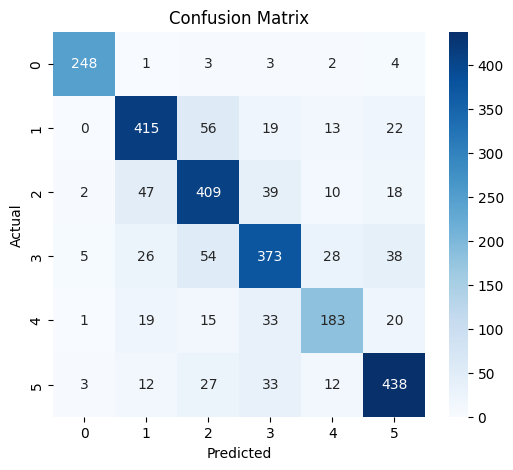

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

labels = np.unique(y_test)
precision = precision_score(
    y_true=y_test,
    y_pred=y_pred,
    labels=labels,
    average=None
)
recall = recall_score(
    y_true=y_test,
    y_pred=y_pred,
    labels=labels,
    average=None
)
f1_score = f1_score(
    y_true=y_test,
    y_pred=y_pred,
    labels=labels,
    average=None
)

df = pd.DataFrame({
    "Class": labels,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1_score
})

display(
    df.style
      .hide(axis="index")
      .background_gradient(cmap="RdYlGn", subset=["Precision", "Recall", "F1 score"])
      .format("{:.3f}", subset=["Precision", "Recall", "F1 score"])
      .set_properties(**{
          "text-align": "center",
          "font-size": "12pt"
      })
      .set_table_styles([
          {"selector": "th", "props": [("text-align", "center"),
                                       ("font-size", "12pt"),
                                       ("font-weight", "bold")]}
      ])
)

Class,Precision,Recall,F1 score
0,0.958,0.950,0.954
1,0.798,0.790,0.794
2,0.725,0.779,0.751
3,0.746,0.712,0.729
4,0.738,0.675,0.705
5,0.811,0.834,0.823


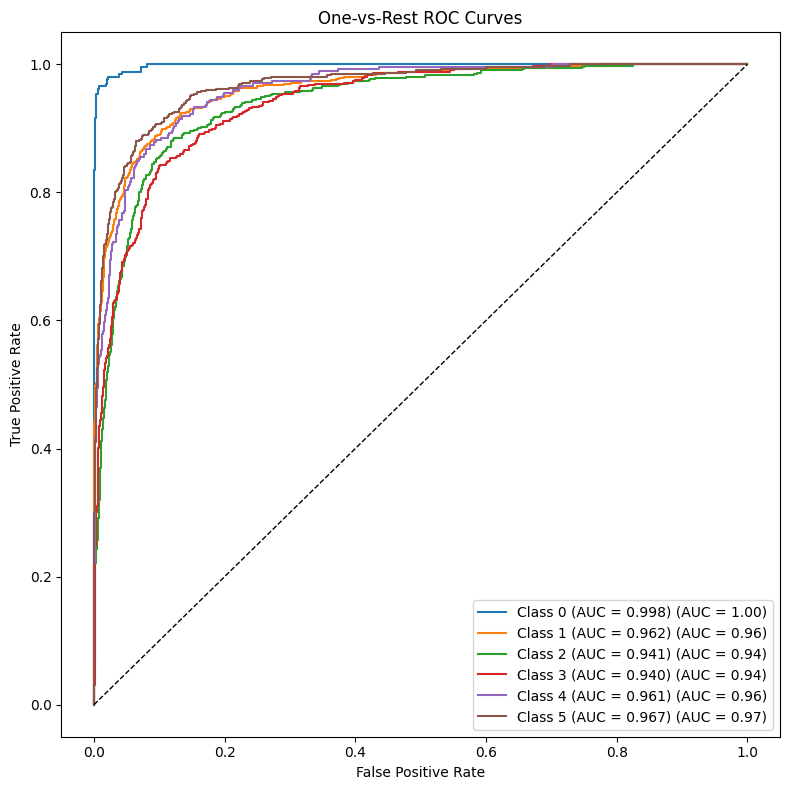

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Predicted probabilities
y_score = final_model.predict_proba(X_test)

# Unique class labels
labels = np.unique(y_test)

# One-hot encode true labels
y_test_bin = label_binarize(y_test, classes=labels)

fig, ax = plt.subplots(figsize=(8, 8))

for i, label in enumerate(labels):
    auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])

    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"Class {label} (AUC = {auc:.3f})",
        ax=ax,
    )

# Chance line
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("One-vs-Rest ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()